In [24]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from functools import partial
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from src.loading import *
from src.plotting import *
from src.saving import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
combined_feature_data = load_combined_features()

Loading combined features from /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/data/combined_features.pkl...


# Map Distributions

In [46]:
def map_data(
    df: pl.DataFrame,
    data_to_bin=None,
    lat_coord="mean_latitude",
    lon_coord="mean_longitude",
    dx=2.5,
    statistic="count",
    normalize=False,
    norm=colors.Normalize(vmin=0.0, vmax=0.25),
    cmap=plt.cm.plasma,
    coastline_color="white",
    extend="max",
    ax=None,
    ticks=None
):
    lat_bins = np.arange(-90, 90 + dx, dx)
    lon_bins = np.arange(-180, 180 + dx, dx)

    lat = df[lat_coord].to_numpy()
    lon = df[lon_coord].to_numpy()

    lon = ((lon + 180) % 360) - 180

    stat = stats.binned_statistic_2d(
        x=lon,
        y=lat,
        values=data_to_bin,
        statistic=statistic,
        bins=[lon_bins, lat_bins],
    ).statistic

    # binned_statistic_2d returns [x_bin, y_bin]
    # pcolormesh wants [y, x]
    data = stat.T

    if normalize:
        data = 100 * data / np.nansum(data)

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(6,3),
            subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
        )
    else:
        fig = ax.get_figure()

    im = ax.pcolormesh(
        lon_bins,
        lat_bins,
        data,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )

    cb = fig.colorbar(
        im,
        orientation="horizontal",
        aspect=40,
        pad=0.15,
        extend=extend,
    )
    if ticks is not None:
        cb.ax.set_xticks(ticks)
    

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        xlocs=[-160, -90, 0, 90, 160],
        ylocs=np.arange(-60, 60, 15),
        linewidth=1,
        linestyle="dotted",
        color="darkgrey",
        alpha=1,
    )
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.right_labels = True
    gl.top_labels = False

    ax.coastlines(color=coastline_color, linewidth=0.75)

    EPS = 1e-6
    ax.set_extent([-180 + EPS, 180 - EPS, -22, 22], crs=ccrs.PlateCarree())
    
    return fig, ax, data

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GPM_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/gSAM_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ICON_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/SCREAM_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GEOS_PF_map.pdf as PDF ...


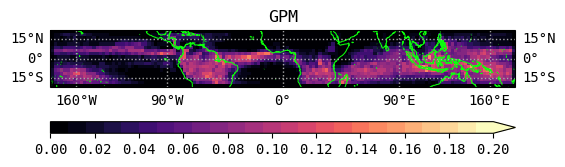

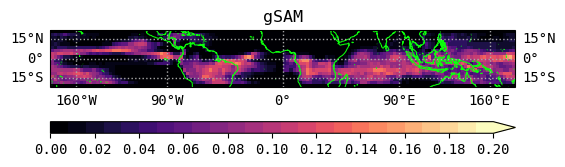

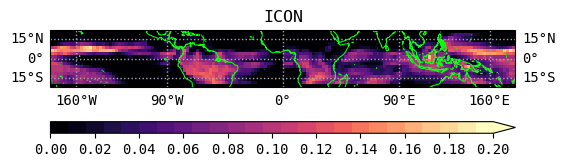

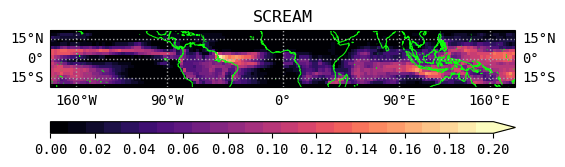

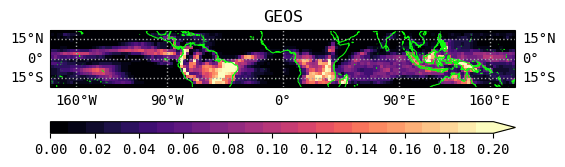

In [49]:
for model_name, df in combined_feature_data.items():
    fig, ax, _ = map_data(
        df,
        normalize=True,
        cmap=discrete_cmap('magma', N=25, under_color='White'),
        norm=colors.Normalize(vmin=0.0, vmax=0.2),
        coastline_color='xkcd:neon green',
        ticks=[0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]
    )
    ax.set_title(f'{model_name}', fontsize=12)
    save_figure(fig, f'{model_name}_PF_map.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GPM_extreme_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/gSAM_extreme_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ICON_extreme_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/SCREAM_extreme_PF_map.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GEOS_extreme_PF_map.pdf as PDF ...


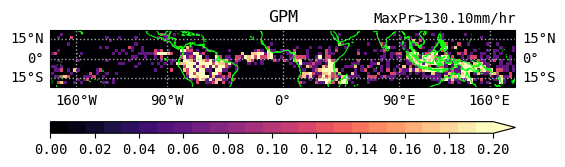

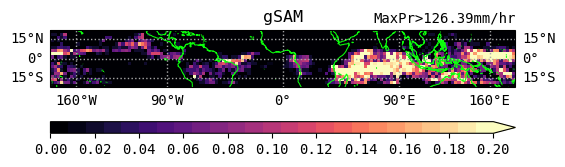

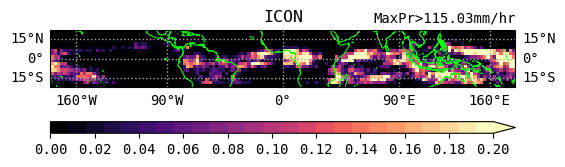

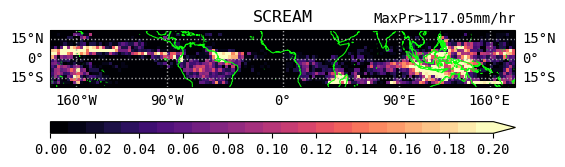

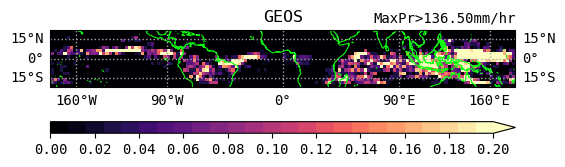

In [51]:
for model_name, df in combined_feature_data.items():
    extreme_thresh = df["max_precip"].quantile(0.99)
    extreme_df = df.filter(pl.col("max_precip") >= extreme_thresh)
    fig, ax, _ = map_data(
        extreme_df,
        normalize=True,
        cmap=discrete_cmap('magma', N=25, under_color='White'),
        norm=colors.Normalize(vmin=0.0, vmax=0.2),
        coastline_color='xkcd:neon green',
        ticks=[0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]
    )
    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_title(f'MaxPr>{extreme_thresh:.2f}mm/hr', loc='right', fontsize=10)
    save_figure(fig, f'{model_name}_extreme_PF_map.pdf')